In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_merged.csv')
df.shape
print(df)

       SEQN  RIDAGEYR  RIDRETH3  BMXBMI  LBXGH  DIQ010      race_ethnicity  \
0     73557        69         4    26.7   13.9     1.0  Non-Hispanic Black   
1     73558        54         3    28.6    9.1     1.0  Non-Hispanic White   
2     73559        72         3    28.9    8.9     1.0  Non-Hispanic White   
3     73561        73         3    19.7    4.9     2.0  Non-Hispanic White   
4     73562        56         1    41.7    5.5     2.0    Mexican American   
...     ...       ...       ...     ...    ...     ...                 ...   
6563  83721        52         3    25.6    5.4     2.0  Non-Hispanic White   
6564  83723        61         1    33.1    7.4     1.0    Mexican American   
6565  83724        80         3    24.9    5.5     2.0  Non-Hispanic White   
6566  83727        26         2    24.5    5.0     2.0      Other Hispanic   
6567  83729        42         4    34.0    5.3     2.0  Non-Hispanic Black   

     diabetes_status  
0           Diabetes  
1           Diabe

In [4]:
df['diabetes_status'].value_counts()

diabetes_status
Normal         4487
Prediabetes    1490
Diabetes        591
Name: count, dtype: int64

In [5]:
df['race_ethnicity'].value_counts()

race_ethnicity
Non-Hispanic White    2638
Non-Hispanic Black    1348
Mexican American      1016
Non-Hispanic Asian     731
Other Hispanic         607
Other/Multiracial      228
Name: count, dtype: int64

In [6]:
df['BMXBMI'].describe()

count    6568.000000
mean       28.226233
std         7.297158
min        13.400000
25%        23.100000
50%        27.100000
75%        31.800000
max        82.900000
Name: BMXBMI, dtype: float64

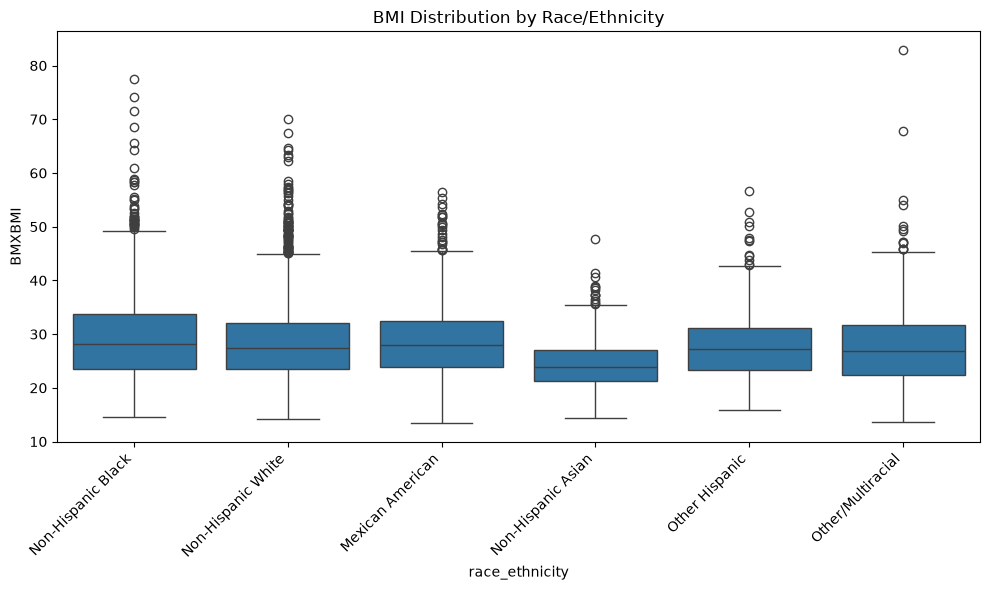

In [10]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'race_ethnicity', y = 'BMXBMI')
plt.xticks(rotation = 45, ha = 'right')
plt.title('BMI Distribution by Race/Ethnicity')
plt.tight_layout()
plt.show()

In [11]:
pd.crosstab(df['race_ethnicity'], df['diabetes_status'], normalize = 'index').round(3)

diabetes_status,Diabetes,Normal,Prediabetes
race_ethnicity,,,
Mexican American,0.101,0.703,0.196
Non-Hispanic Asian,0.094,0.668,0.238
Non-Hispanic Black,0.102,0.585,0.314
Non-Hispanic White,0.082,0.723,0.195
Other Hispanic,0.091,0.679,0.231
Other/Multiracial,0.044,0.781,0.175


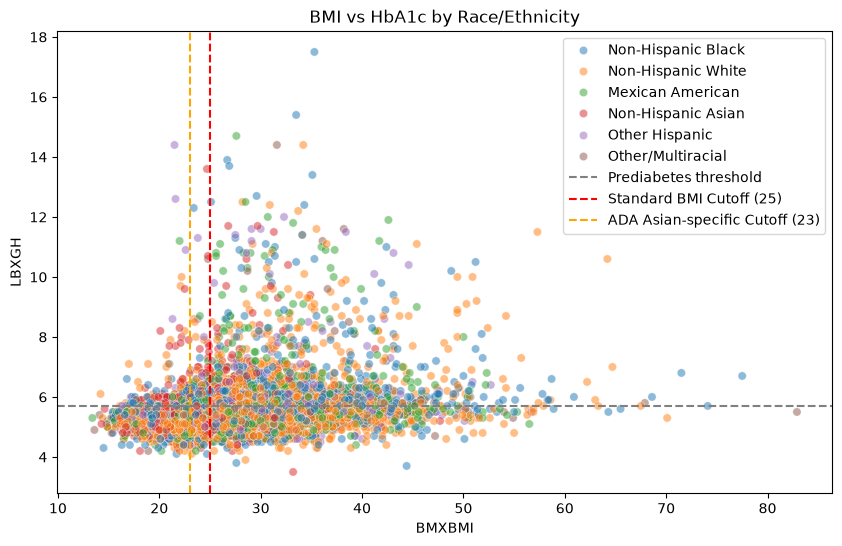

In [16]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = 'BMXBMI', y = 'LBXGH', hue = 'race_ethnicity', alpha = 0.5)
plt.axhline(y = 5.7, color = 'gray', linestyle = '--', label = 'Prediabetes threshold')
plt.axvline(x = 25, color = 'red', linestyle = '--', label = 'Standard BMI Cutoff (25)')
plt.axvline(x = 23, color = 'orange', linestyle = '--', label = 'ADA Asian-specific Cutoff (23)')
plt.legend()
plt.title('BMI vs HbA1c by Race/Ethnicity')
plt.savefig('../docs/bmi_hba1c_scatter.png', dpi = 150, bbox_inches = 'tight')
plt.show()


From looking at it, Asian population tends to show higher HbA1c at lower BMI compared to other populations.
Note that this is not a rigorous result. Next, we will produce a rigorous result with using logistic regression with an interaction term.